# Active SINDy

Recovering governing equations from limited data is a fundamental problem in the modeling of nonlinear partial differential equations. Data-driven frameworks like SINDy remain **sensitive to noise and to undersampling in space and time**. Interested readers may read the study carried out by [(Champion et al, 2019)](https://epubs.siam.org/doi/abs/10.1137/18M1188227) for more information on sampling frequency and duration.

The active learning approach presented here builds on Ensemble-SINDy and selects initial conditions from which to sample very short trajectories, guided by model disagreement across an ensemble of individual SINDy models. This strategy improves robustness and reduces the number of samples required for accurate model identification. This tutorial includes an implementation for the Lorenz system; further details on PDE applications can be found in the paper by [(Larrañaga et al, 2026)](https://doi.org/10.48550/arXiv.2606.12182).

In [1]:
# Import Statements

import os
import numpy as np
from scipy.integrate import solve_ivp
from scipy.stats.qmc import LatinHypercube
import matplotlib.pyplot as plt
from IPython.display import Math, display
import warnings
warnings.filterwarnings('ignore')

from sindy.odes import lorenz
from sindy.library import poly_lib
from sindy.utils import set_seed, print_latex_eqn
from sindy.plot_utils import init_plt_format
from sindy.active.active_sindy import (
    calculate_rms,
    run_active_sindy,
    run_random_sindy,
    run_stats,
    plot_convergence_statistics,
)

init_plt_format()
set_seed(42)

## Core idea

At every iteration Active SINDy:

1. Fits a **bootstrap library ensemble** on the data collected so far.
2. Samples a pool of **candidate initial conditions (ICs)** via Latin Hypercube Sampling (LHS).
3. Evaluates the **ensemble variance** at each candidate — high variance ↔ high uncertainty.
4. **Queries** the trajectory starting from the most uncertain IC and adds it to the training set.
5. Repeats until a convergence criterion on model sparsity and coefficient uncertainty is met.

The intuition: trajectories in regions where the ensemble models disagree the most carry the greatest *information gain* about the true dynamics.

## Convergence criterion

For this example, convergence is reached when **both** conditions hold for `patience` consecutive iterations:
- The model **sparsity** (number of non-zero coefficients) is unchanged.
- The maximum **relative Median Absolute Deviation (MAD)** across all coefficients is below a threshold:

$$\text{rel-MAD}_{ij} = 100\% \times \frac{\text{MAD}(\xi_{ij})}{|\hat{\xi}_{ij}| + \varepsilon}$$

# Applying Active SINDy to the Lorenz System

## Initial Data Generation

We use the **Lorenz system** as our test case because it is chaotic: small changes in IC lead to very different trajectories, making the choice of IC non-trivial. The system is defined by

$$
\begin{aligned}
    \dot{x} &= \sigma(y - x), \\
    \dot{y} &= x(\rho - z) - y, \\
    \dot{z} &= xy - \beta z,
\end{aligned}
$$

with $\sigma = 10$, $\rho = 28$, $\beta = 8/3$.

In [2]:
sigma, beta, rho = 10.0, 8.0 / 3.0, 28.0
lorenz_params = (sigma, beta, rho)
feature_names = ['x', 'y', 'z']
n_dims = len(feature_names)

def get_true_lorenz_coeffs(lib_names: list[str]) -> np.ndarray:
    """Build the true Lorenz coefficient matrix for the given library features."""

    true_map = {
        'x': {'y': sigma,  'x': -sigma},
        'y': {'x': rho,    'x z': -1.0, 'y': -1.0},
        'z': {'x y': 1.0,  'z': -beta},
    }
    feat_idx = {name: i for i, name in enumerate(lib_names)}
    coeffs = np.zeros((len(lib_names), n_dims))
    for j, var in enumerate(feature_names):
        for term, val in true_map.get(var, {}).items():
            if term in feat_idx:
                coeffs[feat_idx[term], j] = val
    return coeffs

The hyperparameters involved in the loop are:

| Group | Parameter | Value | Note |
|---|---|---|---|
| Data | `dt` | 0.01 | Time step |
| Data | `t_span` | (0, 0.1) | Short trajectory per query |
| Data | `n_initial_samples` | 1 | ICs in the seed dataset |
| Data | `relative_noise_factor` | 0.05 | 5 % RMS noise |
| Library | `poly_degree` | 2 | Polynomial degree, no bias |
| Differentiation | `smoother_window` | 7 | Savitzky-Golay window — matches `SmoothedFiniteDifference(window_length=7)` |
| Ensemble | `lam` | 0.5 | STRidge sparsity threshold |
| Ensemble | `l2_norm` | 0.1 | STRidge L2 regularisation |
| Ensemble | `n_ensemble` | 100 | Models per iteration |
| Active | `n_candidates` | 100 | Candidate ICs per iteration |
| Active | `max_iter` | 1000 | Max active learning iterations |
| Active | `patience` | 2 | Sparsity stability patience (number of iterations of constant sparsity levels to consider it as converged) |
| Active | `conv_thresh_coef` | 5.0 | Max rel-MAD (%) for convergence |

In [3]:
# --- Data ---
dt = 0.01
t_span = (0, 0.1)
n_initial_samples = 1
relative_noise_factor = 0.05
state_space_bounds = np.array([[-25, 25], [-35, 35], [0, 55]])
ic_ranges          = np.array([[-15, 15], [-20, 20], [10, 40]])

# --- Library & differentiation ---
poly_degree     = 2
smoother_window = 7 

# --- Ensemble ---
lam        = 0.5    
l2_norm    = 0.1
n_ensemble = 100

# --- Active learning ---
n_candidates     = 100
max_iterations   = 500
patience         = 2
conv_thresh_coef = 5.0    # % relative MAD

We seed the active learning loop with a **single** short trajectory whose IC is sampled via LHS inside the Lorenz attractor bounds. Relative Gaussian noise is added to simulate realistic measurements.

In [4]:
num_pts = int(round((t_span[1] - t_span[0]) / dt)) + 1
t_eval  = np.linspace(t_span[0], t_span[1], num_pts)

sampler_ic = LatinHypercube(d=n_dims, seed=43)
initial_conditions_lhs = (
    ic_ranges[:, 0]
    + (ic_ranges[:, 1] - ic_ranges[:, 0]) * sampler_ic.random(n=n_initial_samples)
)

integrator_kws = dict(method='LSODA', rtol=1e-12, atol=1e-12)
x_initial_list, t_initial_list = [], []

for ic in initial_conditions_lhs:
    sol = solve_ivp(lorenz, t_span, ic, t_eval=t_eval,
                    args=lorenz_params, **integrator_kws)
    if sol.status == 0 and sol.y.shape[1] == num_pts:
        x_traj = sol.y.T
        noise_std = calculate_rms(x_traj) * relative_noise_factor
        x_initial_list.append(x_traj + np.random.normal(0, noise_std, x_traj.shape))
        t_initial_list.append(sol.t)

print(f"Seed dataset: {len(x_initial_list)} trajectory, "
      f"{sum(len(t) for t in t_initial_list)} data points.")

Seed dataset: 1 trajectory, 11 data points.


In [5]:
# Get library feature names via poly_lib (for display only)
_, lib_names = poly_lib(
    x_initial_list[0], power=2,
    include_bias=False, feature_names=feature_names
)
lorenz_coeffs_true = get_true_lorenz_coeffs(lib_names)

print("Library features:", lib_names)
print("True coefficient matrix shape (l, n_dims):", lorenz_coeffs_true.shape)

Library features: ['x', 'y', 'z', 'x^2', 'x y', 'x z', 'y^2', 'y z', 'z^2']
True coefficient matrix shape (l, n_dims): (9, 3)


## Defining Active SINDy Hyperparameters
Several aspects of tuning the active learning hyperparameters deserve attention. To understand and observe the improvement that active learning provides over random sampling for a simple case like Lorenz, we ran a thorough comparison that repeats the convergence process for **10 and 100 candidates**, as well as for **100 runs** with very stiff convergence criteria, which requires substantial computational resources.

You do **not** need such strict settings to benefit from the sampling approach:

- The requirement for a low relative MAD depends on your application and interest.
- The number of repetitions used to obtain statistical relevance is generally unnecessary for practical use — it mainly supports the comparison above.

We encourage you to experiment with these parameters. If you would rather inspect the results of an exhaustive run directly, the pre-saved results are available in `stats_active_random`.

In [6]:
params = dict(
    ode=lorenz,
    ode_params=lorenz_params,
    n_dims=n_dims,
    feature_names=feature_names,
    poly_degree=poly_degree,
    smoother_window=smoother_window,
    lam=lam,
    l2_norm=l2_norm,
    n_ensemble=n_ensemble,
    state_bounds=state_space_bounds,
    t_span_query=t_span,
    dt=dt,
    n_candidates=n_candidates,
    max_iter=max_iterations,
    patience=patience,
    conv_thresh_coef=conv_thresh_coef,
    relative_noise_factor=relative_noise_factor,
    initial_conditions_lhs=initial_conditions_lhs,
    true_coeffs=lorenz_coeffs_true,
)

# True number of non-zero Lorenz coefficients (reference line on L0 plot)
true_sparsity = int(np.count_nonzero(lorenz_coeffs_true))

## Running Active SINDy

A single run of each strategy is subject to randomness (seed data, LHS draws, ensemble subsampling). To get reliable estimates we repeat each run `n_repetitions` times for every candidate pool size in `cand_list` and collect:

- **Number of iterations to convergence**
- **Max relative MAD per iteration** — shows how quickly the ensemble uncertainty collapses.

In [7]:
cand_list     = [10, 100]
n_repetitions = 2
data_dir      = 'data/'
filepath      = os.path.join(data_dir, "stats_active_random.npz")


if not os.path.exists(filepath):

    # Active SINDy 
    print("=== Active SINDy statistical runs ===")
    stats_active = run_stats(
        x_initial_list, t_initial_list,
        params, cand_list, n_repetitions,
        run_active_sindy
    )

    # Random Sampling 
    print("\n=== Random Sampling statistical runs ===")
    stats_random = run_stats(
        x_initial_list, t_initial_list,
        params, cand_list, n_repetitions,
        run_random_sindy
    )

    np.savez(
        filepath,
        stats_active=stats_active,
        stats_random=stats_random
    )
    print(f"Saved stats_active and stats_random to {filepath}")

else:

    data = np.load(filepath, allow_pickle=True)
    stats_active = data['stats_active'].item()
    stats_random = data['stats_random'].item()

=== Active SINDy statistical runs ===

n_candidates = 10
  Rep 1/2


Iteration: 100%|██████████| 500/500 [00:28<00:00, 17.82it/s]


Active SINDy finished — reached max iterations (500).



Iteration: 100%|██████████| 500/500 [00:27<00:00, 17.90it/s]


Active SINDy finished — reached max iterations (500).


n_candidates = 100
  Rep 1/2


...

Random SINDy finished — reached max iterations (500).


n_candidates = 100
  Rep 1/2


Iteration: 100%|██████████| 500/500 [00:26<00:00, 18.97it/s]


Random SINDy finished — reached max iterations (500).



Iteration: 100%|██████████| 500/500 [00:26<00:00, 19.19it/s]

Random SINDy finished — reached max iterations (500).

Saved stats_active and stats_random to data/stats_active_random.npz


## Visualizing the Results

Plotting convergence statistics to compare active vs random sampling for the Lorenz system

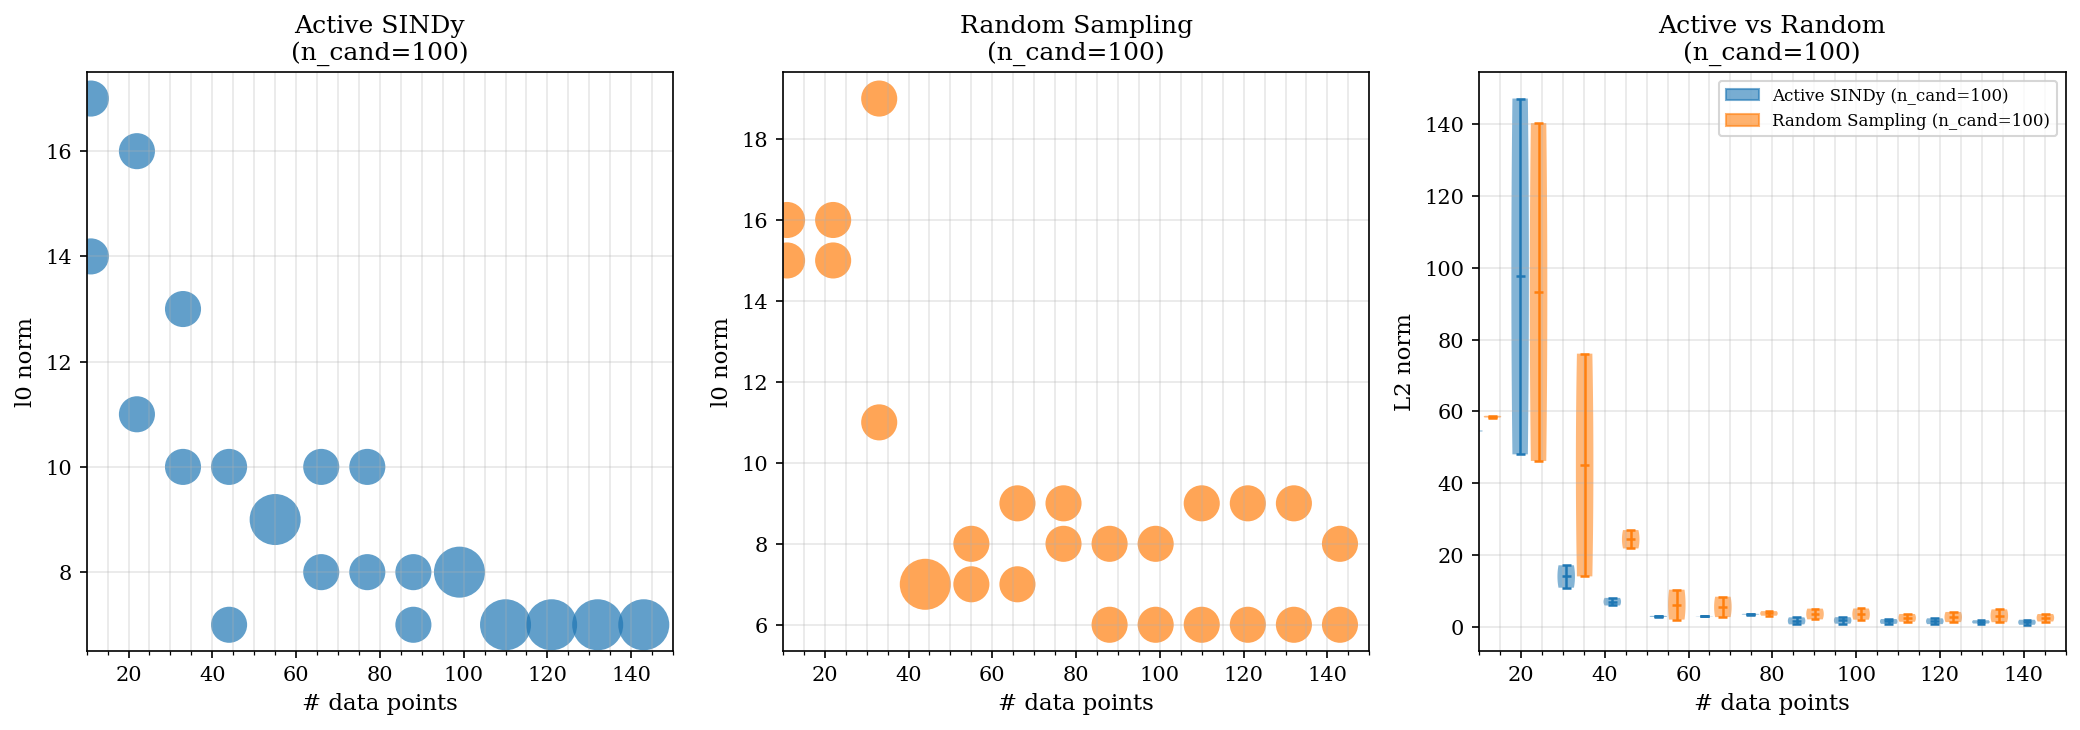

In [8]:
plot_convergence_statistics(
    stats_active, stats_random,
    cand_list,
    true_sparsity=true_sparsity,
    xlim=(10, 150),
)

The combination of active learning with SINDy for dynamics discovery benefits most from applications where certain regions are known to contain more information than others. In such cases, a random sampling strategy would spend too much time in regions that carry little useful information. Fluid flows are a natural example. In the flow past a cylinder, most of the interesting dynamics — vortex shedding, shear layers, and the unsteady wake — are concentrated in a small region downstream of the body, while the surrounding free stream remains nearly uniform. An active strategy would preferentially sample the wake, where the governing terms are hardest to identify, whereas random sampling would waste most of its time on the uninformative free-stream regions.

Further details can be found in the paper by [(Larrañaga et al, 2026)](https://doi.org/10.48550/arXiv.2606.12182).